# Insurance Sales Prediction using Exploratory Data Analysis, Feature Engineering, and Supervised Machine Learning Models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_pinball_loss, make_scorer
 

In [2]:
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [3]:
DATA_PATH = "/kaggle/input/datasets/shayanazmi05/insurances-sales/InsuranceSales.xlsx"


In [4]:
df = pd.read_excel(DATA_PATH, sheet_name="Sales")


# **EDA**

In [5]:
print("Shape:", df.shape)


Shape: (4520, 20)


In [6]:
df.head()


,CustID,AgentBonus,Age,CustTenure,Channel,Occupation,EducationField,Gender,ExistingProdType,Designation,NumberOfPolicy,MaritalStatus,MonthlyIncome,Complaint,ExistingPolicyTenure,SumAssured,Zone,PaymentMethod,LastMonthCalls,CustCareScore
0,7000000,4409,22.0,4.0,Agent,Salaried,Graduate,Female,3,Manager,2.0,Single,20993.0,1,2.0,806761.0,North,Half Yearly,5,2.0
1,7000001,2214,11.0,2.0,Third Party Partner,Salaried,Graduate,Male,4,Manager,4.0,Divorced,20130.0,0,3.0,294502.0,North,Yearly,7,3.0
2,7000002,4273,26.0,4.0,Agent,Free Lancer,Post Graduate,Male,4,Exe,3.0,Unmarried,17090.0,1,2.0,NaN,North,Yearly,0,3.0
3,7000003,1791,11.0,NaN,Third Party Partner,Salaried,Graduate,Fe male,3,Executive,3.0,Divorced,17909.0,1,2.0,268635.0,West,Half Yearly,0,5.0
4,7000004,2955,6.0,NaN,Agent,Small Business,UG,Male,3,Executive,4.0,Divorced,18468.0,0,4.0,366405.0,West,Half Yearly,2,5.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4520 entries, 0 to 4519
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustID                4520 non-null   int64  
 1   AgentBonus            4520 non-null   int64  
 2   Age                   4251 non-null   float64
 3   CustTenure            4294 non-null   float64
 4   Channel               4520 non-null   object 
 5   Occupation            4520 non-null   object 
 6   EducationField        4520 non-null   object 
 7   Gender                4520 non-null   object 
 8   ExistingProdType      4520 non-null   int64  
 9   Designation           4520 non-null   object 
 10  NumberOfPolicy        4475 non-null   float64
 11  MaritalStatus         4520 non-null   object 
 12  MonthlyIncome         4284 non-null   float64
 13  Complaint             4520 non-null   int64  
 14  ExistingPolicyTenure  4336 non-null   float64
 15  SumAssured           

In [8]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0].sort_values("missing_count", ascending=False)
missing_df


,missing_count,missing_pct
Age,269,5.95
MonthlyIncome,236,5.22
CustTenure,226,5.00
ExistingPolicyTenure,184,4.07
SumAssured,154,3.41
CustCareScore,52,1.15
NumberOfPolicy,45,1.00


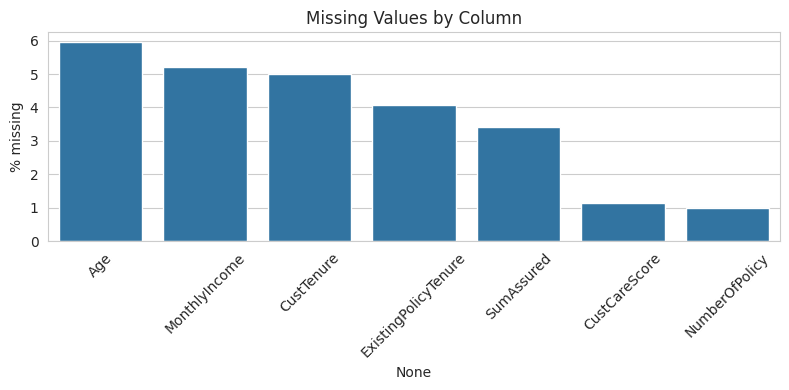

In [9]:
plt.figure(figsize=(8, 4))
sns.barplot(x=missing_df.index, y=missing_df["missing_pct"])
plt.xticks(rotation=45)
plt.ylabel("% missing")
plt.title("Missing Values by Column")
plt.tight_layout()
plt.show()

In [10]:
# Duplicate check
print("Duplicate CustID:", df["CustID"].duplicated().sum())
print("Fully duplicate rows:", df.duplicated().sum())

Duplicate CustID: 0
Fully duplicate rows: 0


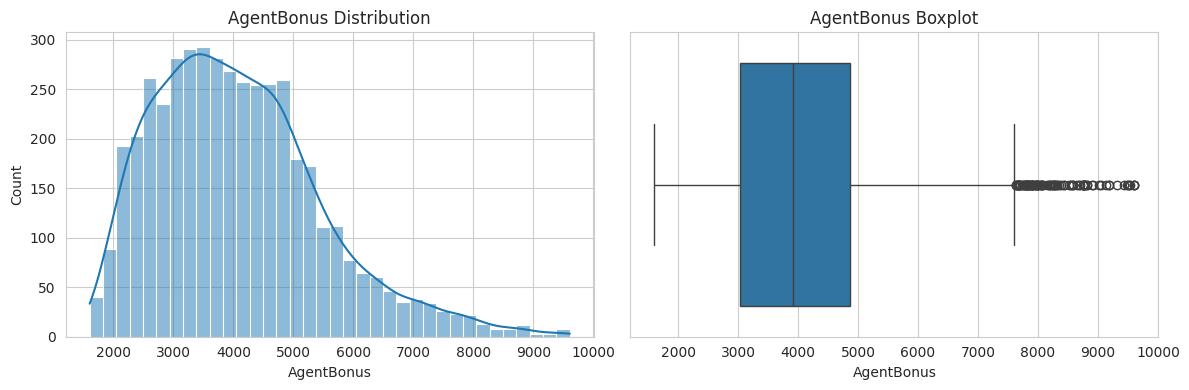

Skewness: 0.822


count    4520.000000
mean     4077.838274
std      1403.321711
min      1605.000000
25%      3027.750000
50%      3911.500000
75%      4867.250000
max      9608.000000
Name: AgentBonus, dtype: float64

In [11]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["AgentBonus"], kde=True, ax=axes[0])
axes[0].set_title("AgentBonus Distribution")
sns.boxplot(x=df["AgentBonus"], ax=axes[1])
axes[1].set_title("AgentBonus Boxplot")
plt.tight_layout()
plt.show()
 
print("Skewness:", df["AgentBonus"].skew().round(3))
df["AgentBonus"].describe()

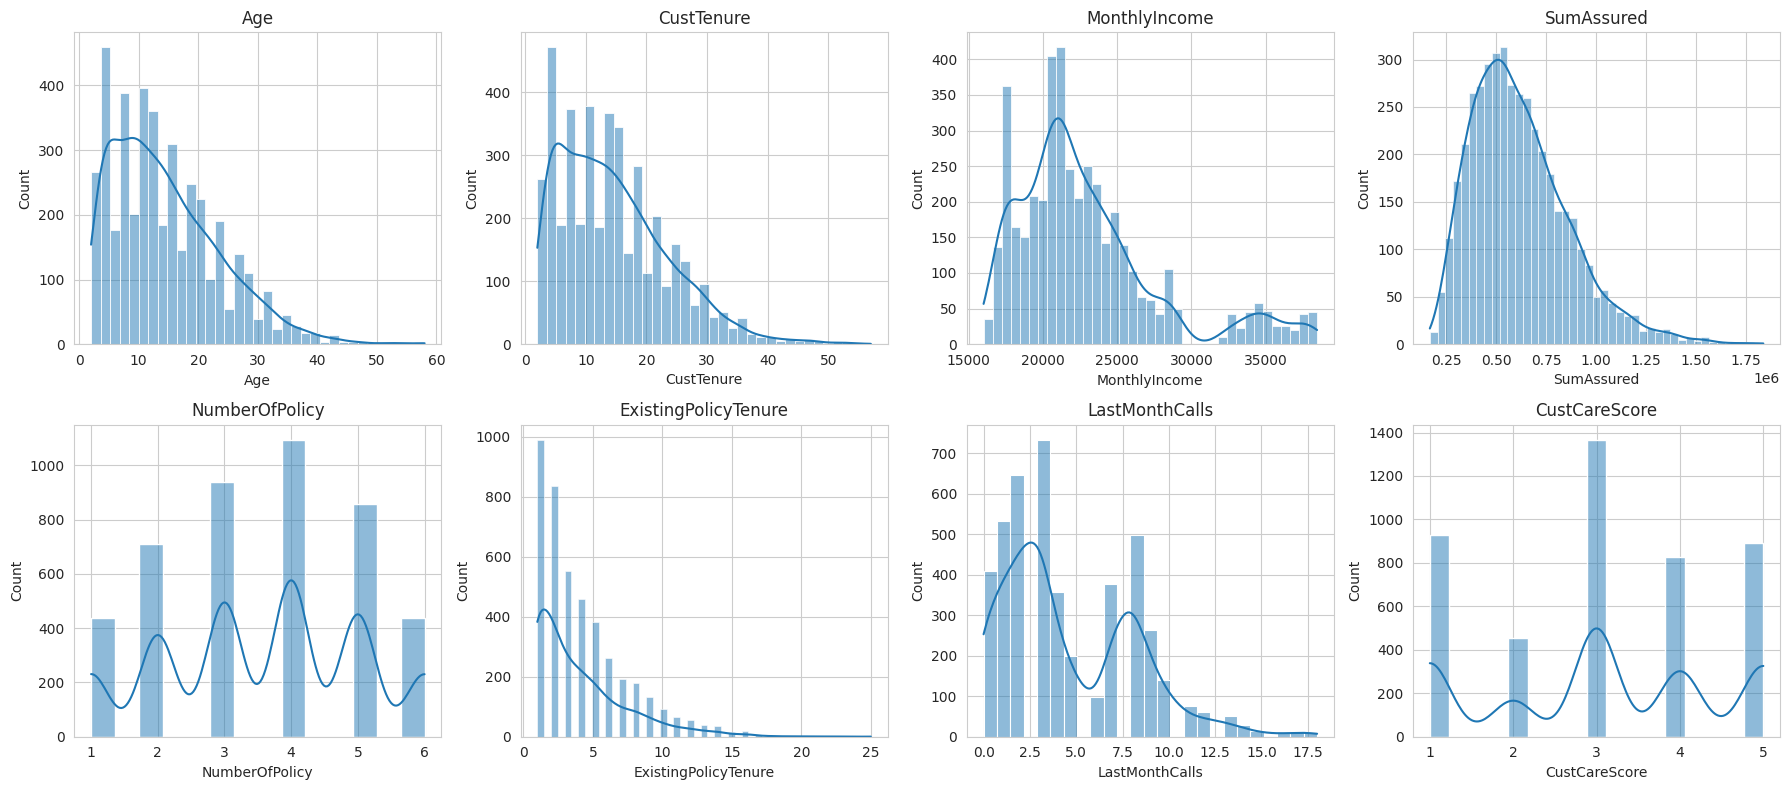

In [12]:
# Numeric feature distributions
numeric_cols = ["Age", "CustTenure", "MonthlyIncome", "SumAssured",
                 "NumberOfPolicy", "ExistingPolicyTenure", "LastMonthCalls", "CustCareScore"]
 
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


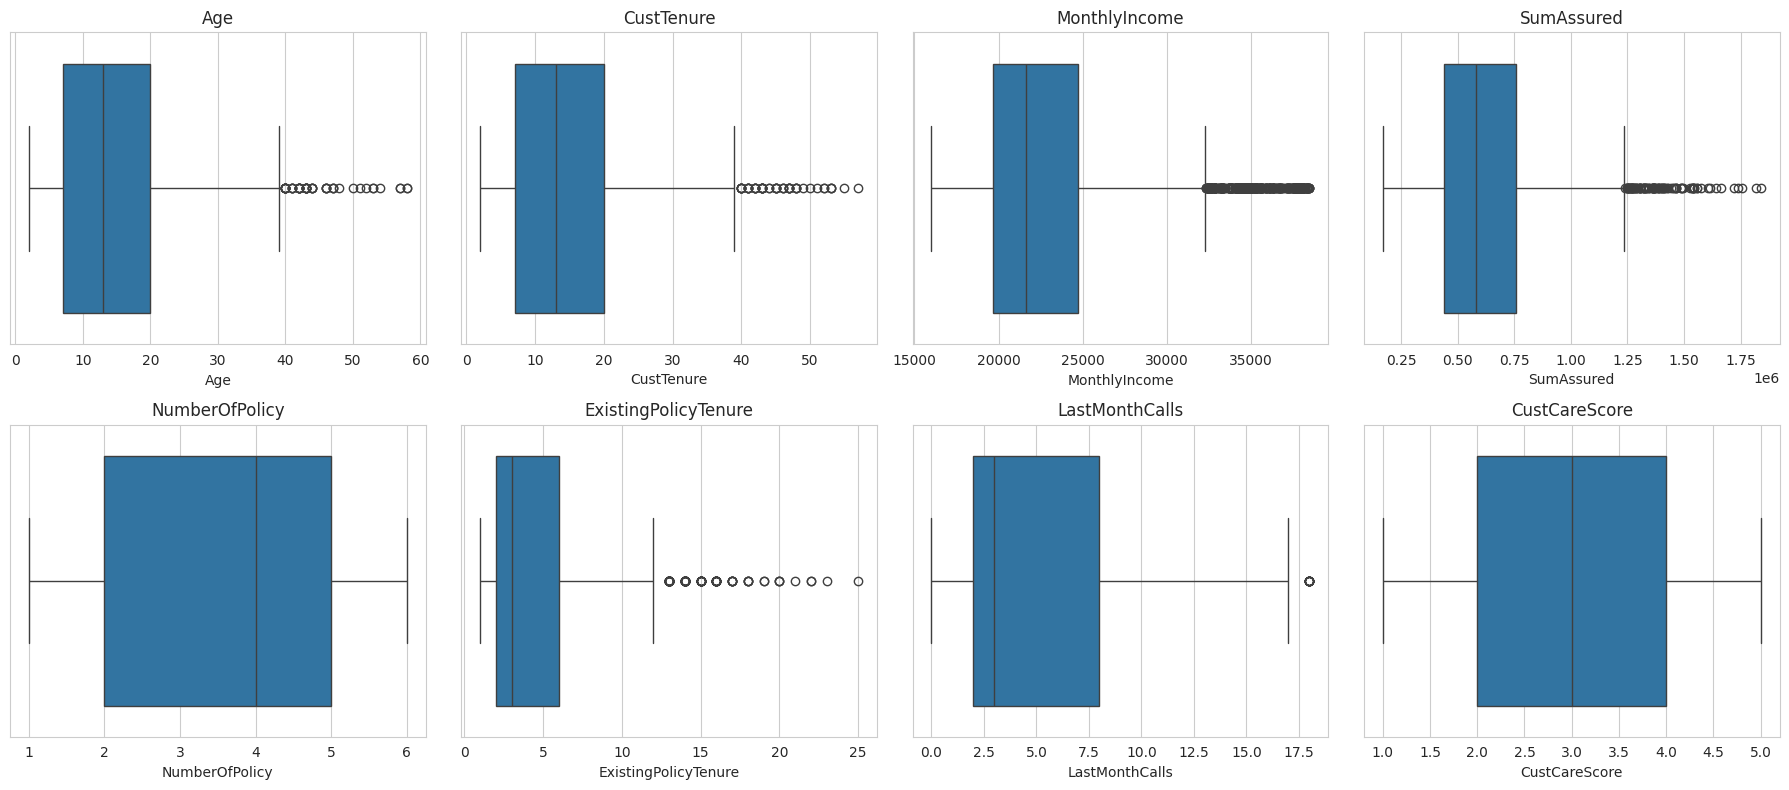

In [13]:
# Outlier check via boxplots
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [14]:
# Categorical feature value counts — also surfaces label inconsistencies (typos/duplicates)
cat_cols = ["Channel", "Occupation", "EducationField", "Gender",
            "Designation", "MaritalStatus", "Zone", "PaymentMethod"]
 
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())
 


--- Channel ---
Channel
Agent                  3194
Third Party Partner     858
Online                  468
Name: count, dtype: int64

--- Occupation ---
Occupation
Salaried           2192
Small Business     1918
Large Business      255
Laarge Business     153
Free Lancer           2
Name: count, dtype: int64

--- EducationField ---
EducationField
Graduate          1870
Under Graduate    1190
Diploma            496
Engineer           408
Post Graduate      252
UG                 230
MBA                 74
Name: count, dtype: int64

--- Gender ---
Gender
Male       2688
Female     1507
Fe male     325
Name: count, dtype: int64

--- Designation ---
Designation
Manager           1620
Executive         1535
Senior Manager     676
AVP                336
VP                 226
Exe                127
Name: count, dtype: int64

--- MaritalStatus ---
MaritalStatus
Married      2268
Single       1254
Divorced      804
Unmarried     194
Name: count, dtype: int64

--- Zone ---
Zone
West     2566


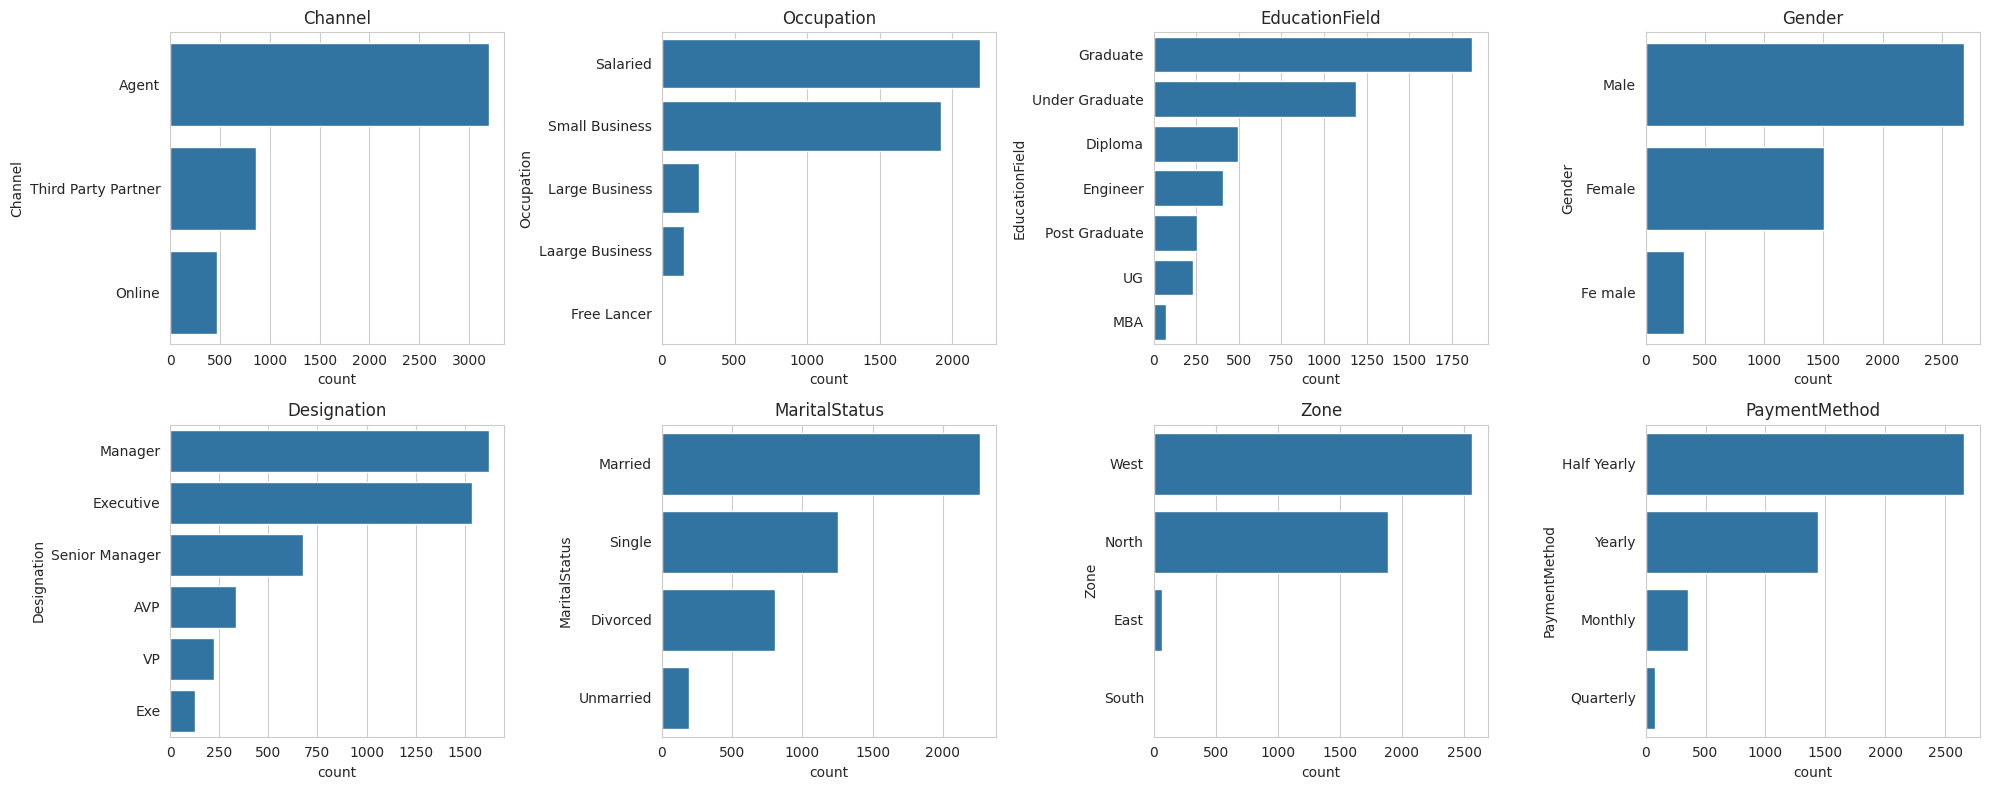

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

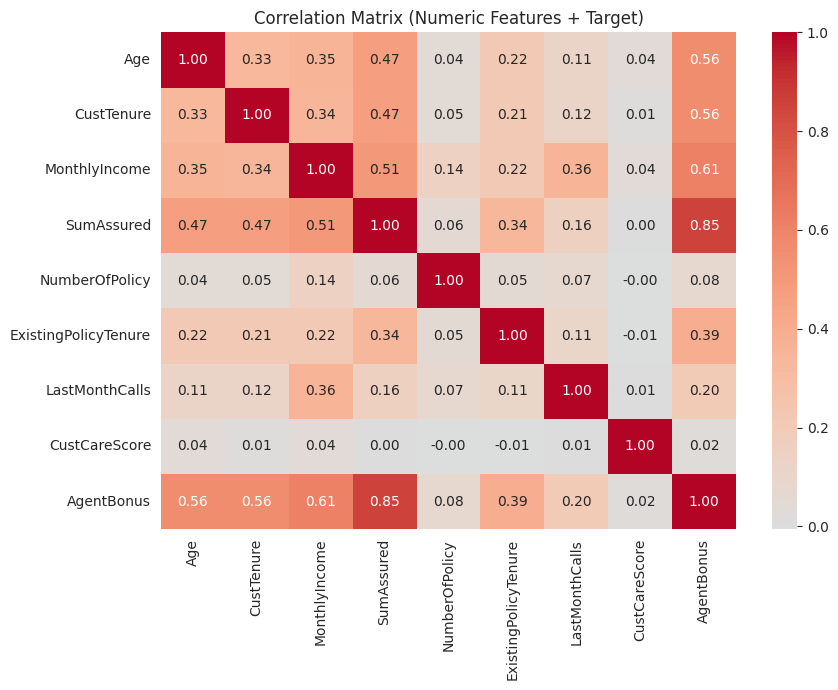


Correlation with AgentBonus (sorted):
AgentBonus              1.000000
SumAssured              0.854257
MonthlyIncome           0.612196
CustTenure              0.561344
Age                     0.559481
ExistingPolicyTenure    0.392415
LastMonthCalls          0.199708
NumberOfPolicy          0.076448
CustCareScore           0.022860
Name: AgentBonus, dtype: float64


In [16]:
# Numeric vs target — correlation
corr_cols = numeric_cols + ["AgentBonus"]
corr = df[corr_cols].corr()
 
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Numeric Features + Target)")
plt.tight_layout()
plt.show()
print("\nCorrelation with AgentBonus (sorted):")
print(corr["AgentBonus"].sort_values(ascending=False))
 

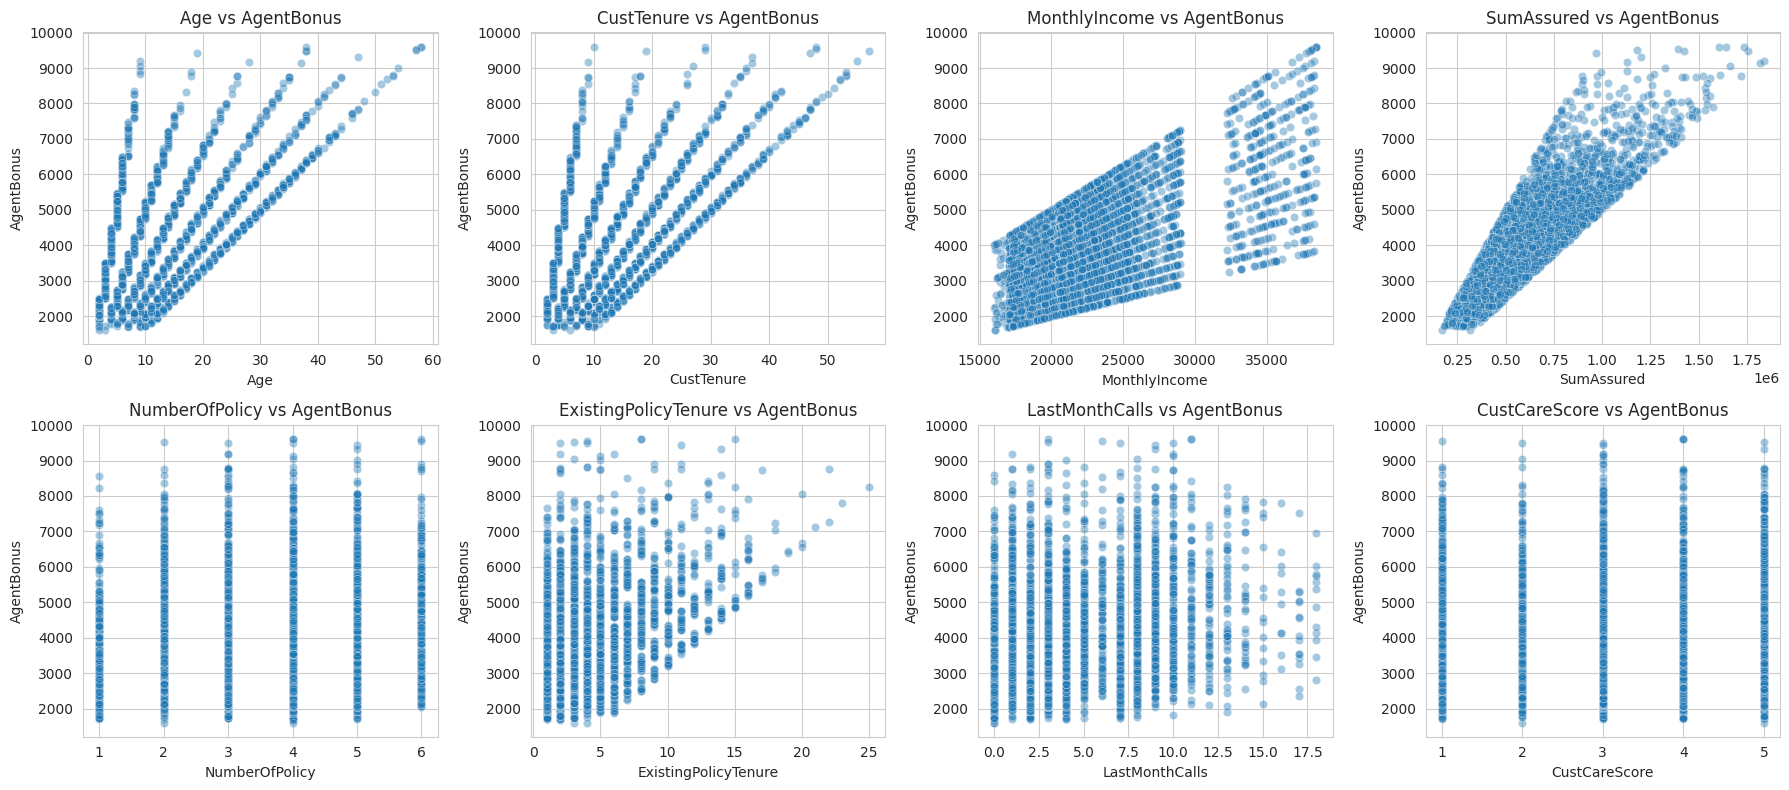

In [17]:
# Scatterplots: numeric features vs target
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.scatterplot(x=df[col], y=df["AgentBonus"], ax=ax, alpha=0.4)
    ax.set_title(f"{col} vs AgentBonus")
plt.tight_layout()
plt.show()
 

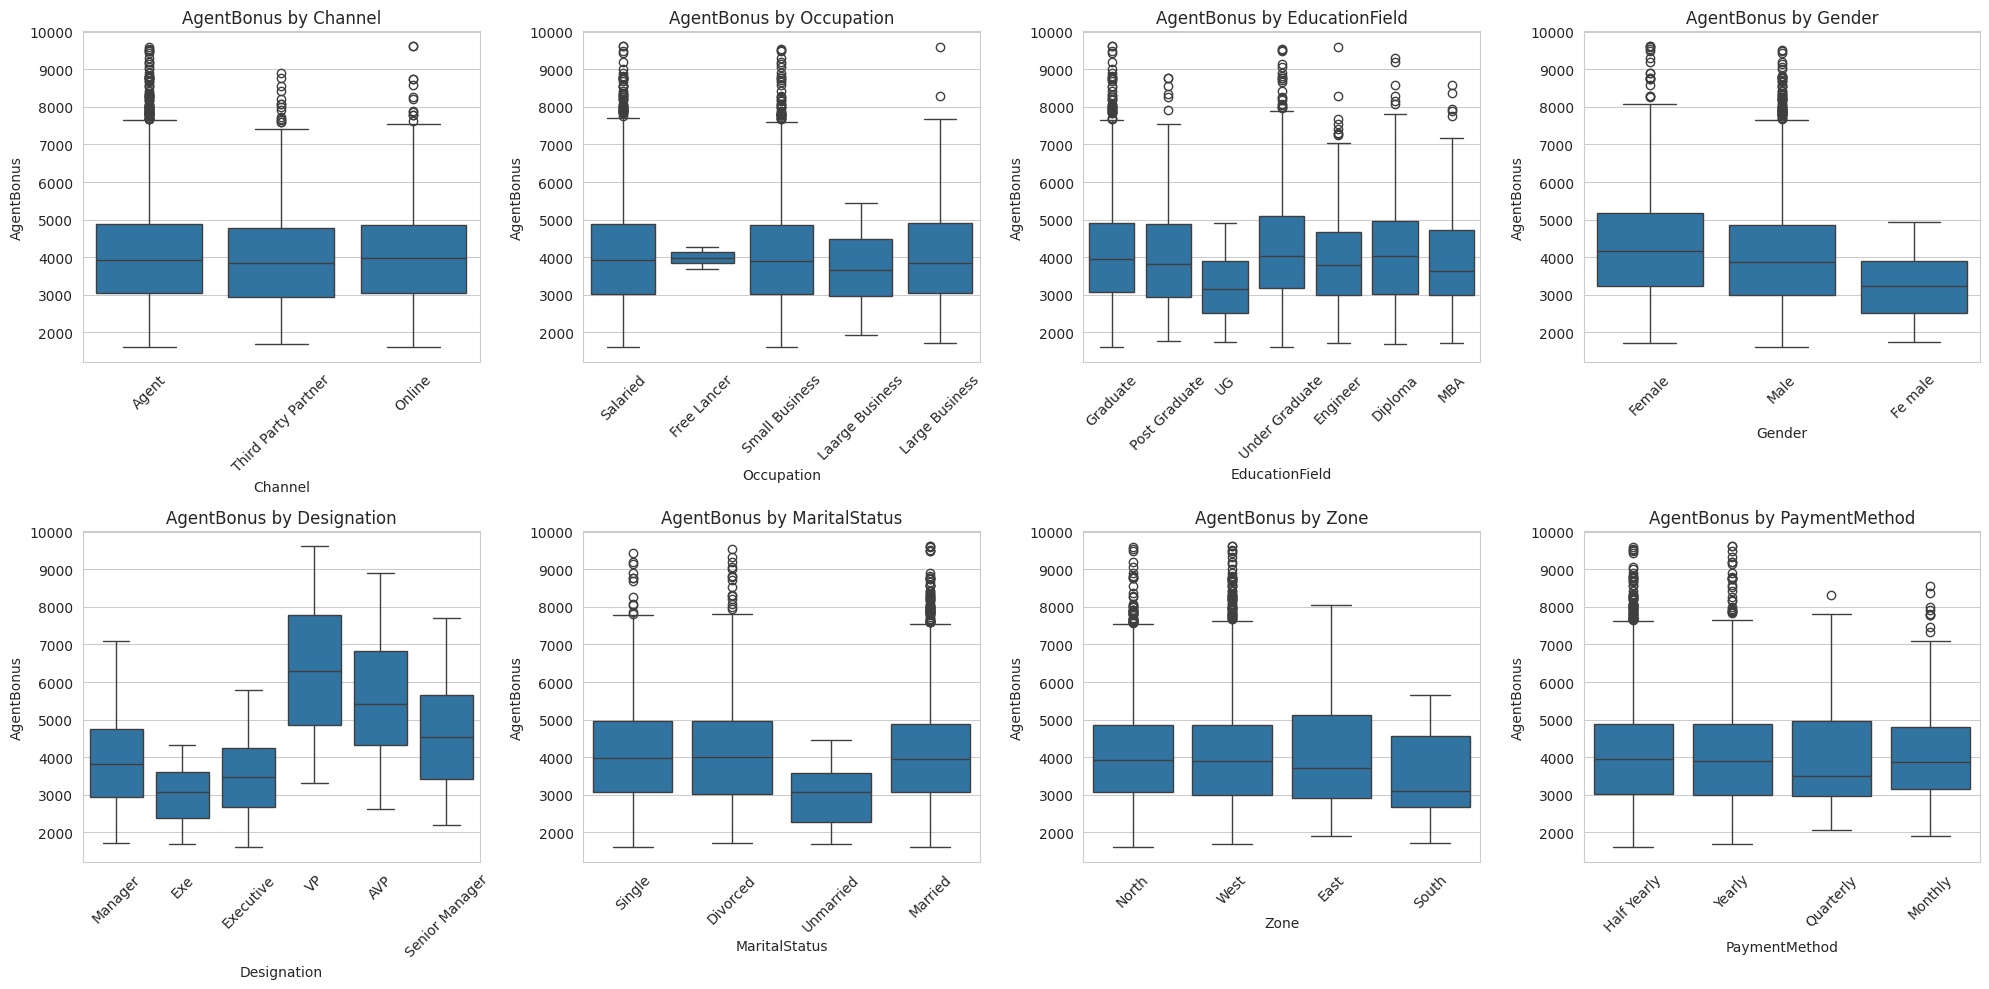

In [18]:
# %%
# Categorical vs target — boxplots
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, col in zip(axes.flatten(), cat_cols):
    sns.boxplot(x=col, y="AgentBonus", data=df, ax=ax)
    ax.tick_params(axis="x", rotation=45)
    ax.set_title(f"AgentBonus by {col}")
plt.tight_layout()
plt.show()
 

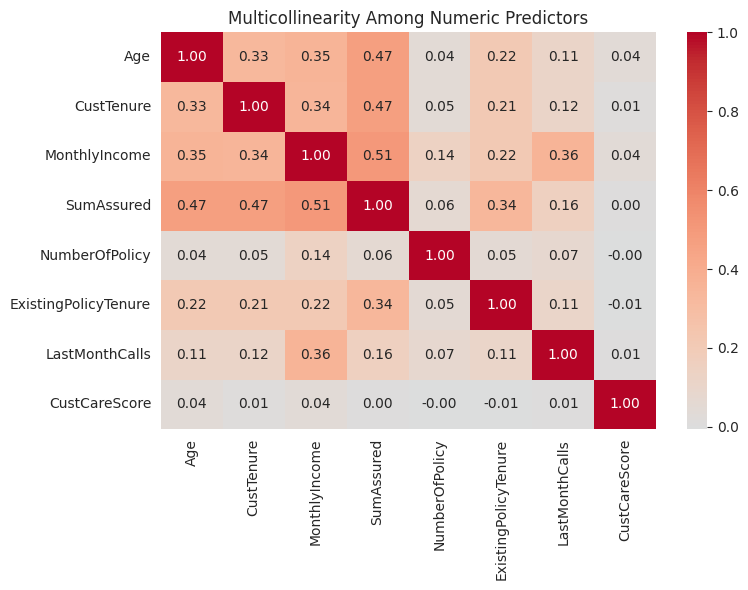

In [19]:
# %%
# Multicollinearity check among predictors (excluding target)
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Multicollinearity Among Numeric Predictors")
plt.tight_layout()
plt.show()
 

In [20]:
# %%
# Missingness vs a key categorical (e.g. is MonthlyIncome missing more for a specific Occupation?)
missing_by_occ = df.groupby("Occupation")["MonthlyIncome"].apply(lambda x: x.isnull().mean() * 100).round(2)
print("MonthlyIncome missing % by Occupation:\n", missing_by_occ)
 

MonthlyIncome missing % by Occupation:
 Occupation
Free Lancer        0.00
Laarge Business    0.00
Large Business     8.63
Salaried           5.47
Small Business     4.90
Name: MonthlyIncome, dtype: float64


In [21]:
# %%
# Quick summary of data-quality issues to fix in preprocessing
print("Gender categories:", df["Gender"].unique())
print("Occupation categories:", df["Occupation"].unique())
print("EducationField categories:", df["EducationField"].unique())
print("Designation categories:", df["Designation"].unique())
print("MaritalStatus categories:", df["MaritalStatus"].unique())
 

Gender categories: ['Female' 'Male' 'Fe male']
Occupation categories: ['Salaried' 'Free Lancer' 'Small Business' 'Laarge Business'
 'Large Business']
EducationField categories: ['Graduate' 'Post Graduate' 'UG' 'Under Graduate' 'Engineer' 'Diploma'
 'MBA']
Designation categories: ['Manager' 'Exe' 'Executive' 'VP' 'AVP' 'Senior Manager']
MaritalStatus categories: ['Single' 'Divorced' 'Unmarried' 'Married']


# **preprocessing**

In [22]:
print("Shape before cleaning:", df.shape)


Shape before cleaning: (4520, 20)


In [23]:
# ## 1. Fix inconsistent category labels
# Found during EDA: typos / duplicate spellings that should be merged.
 
# %%
df["Gender"] = df["Gender"].replace({"Fe male": "Female"})
 
df["Occupation"] = df["Occupation"].replace({"Laarge Business": "Large Business"})
 
df["EducationField"] = df["EducationField"].replace({
    "UG": "Under Graduate"
})
 
df["Designation"] = df["Designation"].replace({"Exe": "Executive"})
 
# MaritalStatus had both 'Single' and 'Unmarried' (194 rows) — these mean
# the same thing, just entered inconsistently. Merging them into one label
# so the model doesn't treat them as two different categories.
df["MaritalStatus"] = df["MaritalStatus"].replace({"Unmarried": "Single"})
 
# Verify fixes
for col in ["Gender", "Occupation", "EducationField", "Designation", "MaritalStatus"]:
    print(col, ":", df[col].unique())
 


Gender : ['Female' 'Male']
Occupation : ['Salaried' 'Free Lancer' 'Small Business' 'Large Business']
EducationField : ['Graduate' 'Post Graduate' 'Under Graduate' 'Engineer' 'Diploma' 'MBA']
Designation : ['Manager' 'Executive' 'VP' 'AVP' 'Senior Manager']
MaritalStatus : ['Single' 'Divorced' 'Married']


In [24]:
# ## 2. Drop identifier column
# CustID carries no predictive signal.
 
# %%
df = df.drop(columns=["CustID"])
 
# %% [markdown]
# ## 3. Train/test split BEFORE imputation
# Why split first: if we fill missing values using the WHOLE dataset's
# median, the test set "leaks" information into training (the model
# indirectly sees test-set patterns). Splitting first, then calculating
# medians only from the training set, keeps the test set truly unseen —
# which gives a more honest estimate of real-world performance.
 
# %%
X = df.drop(columns=["AgentBonus"])
y = df["AgentBonus"]
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
 


Train shape: (3616, 18) Test shape: (904, 18)


In [25]:
# ## 4. Impute missing values
# - MonthlyIncome: group-median by Occupation (EDA showed missingness/level
#   varies by Occupation)
# - Everything else: simple median (numeric) — fit stats on TRAIN only,
#   apply to both train and test to avoid leakage
 
# %%
# --- MonthlyIncome: group-median by Occupation ---
income_medians = X_train.groupby("Occupation")["MonthlyIncome"].median()
overall_income_median = X_train["MonthlyIncome"].median()
 
def fill_income(row_df, medians, fallback):
    filled = row_df["MonthlyIncome"].copy()
    mask = filled.isnull()
    filled.loc[mask] = row_df.loc[mask, "Occupation"].map(medians).fillna(fallback)
    return filled
 
X_train["MonthlyIncome"] = fill_income(X_train, income_medians, overall_income_median)
X_test["MonthlyIncome"] = fill_income(X_test, income_medians, overall_income_median)

In [26]:
# --- Remaining numeric columns: simple median, fit on train only ---
numeric_impute_cols = ["Age", "CustTenure", "NumberOfPolicy",
                        "ExistingPolicyTenure", "SumAssured", "CustCareScore"]
 
train_medians = X_train[numeric_impute_cols].median()
 
X_train[numeric_impute_cols] = X_train[numeric_impute_cols].fillna(train_medians)
X_test[numeric_impute_cols] = X_test[numeric_impute_cols].fillna(train_medians)
 
print("Remaining missing in train:\n", X_train.isnull().sum().sum())
print("Remaining missing in test:\n", X_test.isnull().sum().sum())
 

Remaining missing in train:
 0
Remaining missing in test:
 0


In [27]:
# ## 5. Encode categoricals
# Models only understand numbers, so text categories need converting.
# Two different methods are used here depending on the category type:
# - Designation: ORDINAL encoding (Executive=0, Manager=1, ... VP=4).
#   This is used because Designation has a real ranking (junior to
#   senior), and the EDA boxplot confirmed bonus amounts increase in
#   that exact order. Encoding it as numbers 0-4 lets the model use
#   that ranking directly.
# - Everything else: ONE-HOT encoding (a separate 0/1 column per
#   category, e.g. Zone_North, Zone_West...). This is used because
#   these categories have NO natural order (e.g. "West" isn't higher
#   or lower than "North") — one-hot avoids implying a false ranking.
 
# %%
designation_order = {
    "Executive": 0,
    "Manager": 1,
    "Senior Manager": 2,
    "AVP": 3,
    "VP": 4,
}
X_train["Designation"] = X_train["Designation"].map(designation_order)
X_test["Designation"] = X_test["Designation"].map(designation_order)
 


In [28]:
nominal_cols = ["Channel", "Occupation", "EducationField", "Gender",
                 "MaritalStatus", "Zone", "PaymentMethod"]


In [29]:

# drop_first=True drops one category per column (e.g. keeps Zone_North/
# Zone_South/Zone_West but drops Zone_East). This avoids redundant columns
# that all say the same thing indirectly — a standard step called
# "avoiding the dummy variable trap."
X_train = pd.get_dummies(X_train, columns=nominal_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=nominal_cols, drop_first=True)
 


In [30]:
# Some rare categories (e.g. Zone=South, only 6 rows total) might land
# entirely in train OR entirely in test after the split. That would leave
# train and test with a different number of columns, which breaks model
# training/prediction. This line forces both sets to have identical
# columns, filling any missing one with 0.
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

In [31]:
print("Final train shape:", X_train.shape)
print("Final test shape:", X_test.shape)

Final train shape: (3616, 30)
Final test shape: (904, 30)


In [32]:

X_train.head()
 

,Age,CustTenure,ExistingProdType,Designation,NumberOfPolicy,MonthlyIncome,Complaint,ExistingPolicyTenure,SumAssured,LastMonthCalls,CustCareScore,Channel_Online,Channel_Third Party Partner,Occupation_Large Business,Occupation_Salaried,Occupation_Small Business,EducationField_Engineer,EducationField_Graduate,EducationField_MBA,EducationField_Post Graduate,EducationField_Under Graduate,Gender_Male,MaritalStatus_Married,MaritalStatus_Single,Zone_North,Zone_South,Zone_West,PaymentMethod_Monthly,PaymentMethod_Quarterly,PaymentMethod_Yearly
3779,17.0,28.0,4,4,2.0,37974.0,0,7.0,1099347.0,7,1.0,False,False,False,False,True,False,False,False,False,True,False,True,False,True,False,False,False,False,False
978,16.0,3.0,4,2,5.0,25306.0,0,2.0,638217.0,0,5.0,False,False,False,False,True,False,False,False,False,True,True,True,False,False,False,True,False,False,True
251,5.0,23.0,3,2,3.0,28610.0,1,2.0,856011.0,7,5.0,False,False,False,False,True,False,False,False,False,True,True,False,False,False,False,True,False,False,False
2154,16.0,13.0,4,0,5.0,18196.0,0,1.0,419236.0,3,3.0,False,False,False,False,True,False,False,False,False,True,True,True,False,True,False,False,False,False,True
4100,21.0,18.0,5,1,6.0,25268.0,0,2.0,502328.0,8,3.0,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,True


In [33]:
# ## 6. (Optional) Target transform
# AgentBonus skew was 0.82 — log transform can help linear-style models.
# Tree-based models (RF/XGBoost) don't need this, but it's cheap to keep both.
 
# %%
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)
 


In [34]:
# ## 7. Save processed splits for modeling notebook
 
# %%
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)
print("Saved processed train/test splits.")
 




Saved processed train/test splits.


# **Modeling**

In [35]:
# ## 2. Scaling — only needed for Linear/Ridge/Lasso
# Tree-based models (Decision Tree, Random Forest) split on raw feature
# values and don't care about scale, so they use the unscaled data.
# Linear-style models DO care — a feature like MonthlyIncome (~20,000)
# would otherwise dominate a feature like NumberOfPolicy (~1-6) just
# because of its bigger numbers, not because it's more important.
 
# %%
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit only on train — same leakage rule as before
X_test_scaled = scaler.transform(X_test)          # test only ever gets transformed, never fit

In [36]:
# ## 3. Helper: evaluate a model consistently
# Prints RMSE, MAE, R² on both cross-validation (train) and the held-out
# test set, so we can compare models on the same footing.
 
# %%
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, cv=5):
    # Cross-validation on TRAINING data only — gives a more reliable
    # performance estimate than a single train/test split, since it
    # averages over multiple different splits of the training data.
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    cv_rmse = -cross_val_score(model, X_tr, y_tr, cv=kf,
                                scoring="neg_root_mean_squared_error")
 
    # Fit on the full training set, then score once on the untouched test set
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
 
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    mae = mean_absolute_error(y_te, preds)
    r2 = r2_score(y_te, preds)
 
    print(f"--- {name} ---")
    print(f"CV RMSE (train, mean ± std): {cv_rmse.mean():.1f} ± {cv_rmse.std():.1f}")
    print(f"Test RMSE: {rmse:.1f}")
    print(f"Test MAE:  {mae:.1f}")
    print(f"Test R²:   {r2:.4f}")
    print()
 
    return {"model": name, "cv_rmse": cv_rmse.mean(), "test_rmse": rmse,
            "test_mae": mae, "test_r2": r2, "fitted_model": model}
 
results = []


##  Baseline — Linear Regression
### Simple, fast, fully interpretable. Sets the bar every other model
### needs to beat. If a complex model can't outperform this, it's not
### worth the added complexity.
 

In [37]:
lr = LinearRegression()
results.append(evaluate_model("Linear Regression", lr,
                                X_train_scaled, y_train, X_test_scaled, y_test))
 


--- Linear Regression ---
CV RMSE (train, mean ± std): 622.0 ± 20.3
Test RMSE: 637.8
Test MAE:  501.9
Test R²:   0.7978



##  Ridge & Lasso Regression
### The EDA correlation heatmap showed some multicollinearity between
### numeric features (e.g. SumAssured correlated with MonthlyIncome and
### Age). Ridge/Lasso add a penalty that reduces the impact of that
### redundancy, which plain Linear Regression can't do.



In [38]:
ridge = Ridge(alpha=1.0, random_state=42)
results.append(evaluate_model("Ridge Regression", ridge,
                                X_train_scaled, y_train, X_test_scaled, y_test))
 
lasso = Lasso(alpha=1.0, random_state=42)
results.append(evaluate_model("Lasso Regression", lasso,
                                X_train_scaled, y_train, X_test_scaled, y_test))
 

--- Ridge Regression ---
CV RMSE (train, mean ± std): 622.0 ± 20.3
Test RMSE: 631.1
Test MAE:  495.8
Test R²:   0.8020

--- Lasso Regression ---
CV RMSE (train, mean ± std): 621.4 ± 20.2
Test RMSE: 622.7
Test MAE:  486.8
Test R²:   0.8072



##  Decision Tree Regressor
### Captures non-linear relationships (like the "fan" pattern seen in the
### Age/CustTenure vs AgentBonus scatterplots during EDA) that a straight
### line can't. Uses unscaled data — trees split on raw thresholds, so
### scaling has no effect on them.
 


In [39]:
dt = DecisionTreeRegressor(max_depth=8, min_samples_leaf=10, random_state=42)
results.append(evaluate_model("Decision Tree", dt,
                                X_train, y_train, X_test, y_test))
 

--- Decision Tree ---
CV RMSE (train, mean ± std): 597.5 ± 39.4
Test RMSE: 605.2
Test MAE:  456.6
Test R²:   0.8179



#   Random Forest Regressor
### An ensemble of many decision trees, each trained on a random subset
### of data/features, then averaged. This usually beats a single tree by
### a wide margin because it cancels out each individual tree's overfitting.
 

In [40]:
rf = RandomForestRegressor(n_estimators=300, max_depth=12,
                             min_samples_leaf=5, random_state=42, n_jobs=-1)
results.append(evaluate_model("Random Forest", rf,
                                X_train, y_train, X_test, y_test))
 

--- Random Forest ---
CV RMSE (train, mean ± std): 536.8 ± 31.8
Test RMSE: 532.4
Test MAE:  402.9
Test R²:   0.8591



##  XGBoost 

In [41]:
xgb = XGBRegressor(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)
results.append(evaluate_model("XGBoost", xgb,
                                X_train, y_train, X_test, y_test))
 

--- XGBoost ---
CV RMSE (train, mean ± std): 532.5 ± 23.5
Test RMSE: 522.9
Test MAE:  394.7
Test R²:   0.8640



In [42]:
#Compare all models side by side
 
# %%
results_df = pd.DataFrame(results)[["model", "cv_rmse", "test_rmse", "test_mae", "test_r2"]]
results_df = results_df.sort_values("test_rmse")
print(results_df.to_string(index=False))
 

            model    cv_rmse  test_rmse   test_mae  test_r2
          XGBoost 532.538110 522.923363 394.715424 0.864046
    Random Forest 536.785144 532.427669 402.889931 0.859059
    Decision Tree 597.521383 605.213572 456.635911 0.817890
 Lasso Regression 621.389826 622.658801 486.815702 0.807240
 Ridge Regression 622.001370 631.119330 495.806023 0.801966
Linear Regression 622.021586 637.786196 501.916738 0.797760


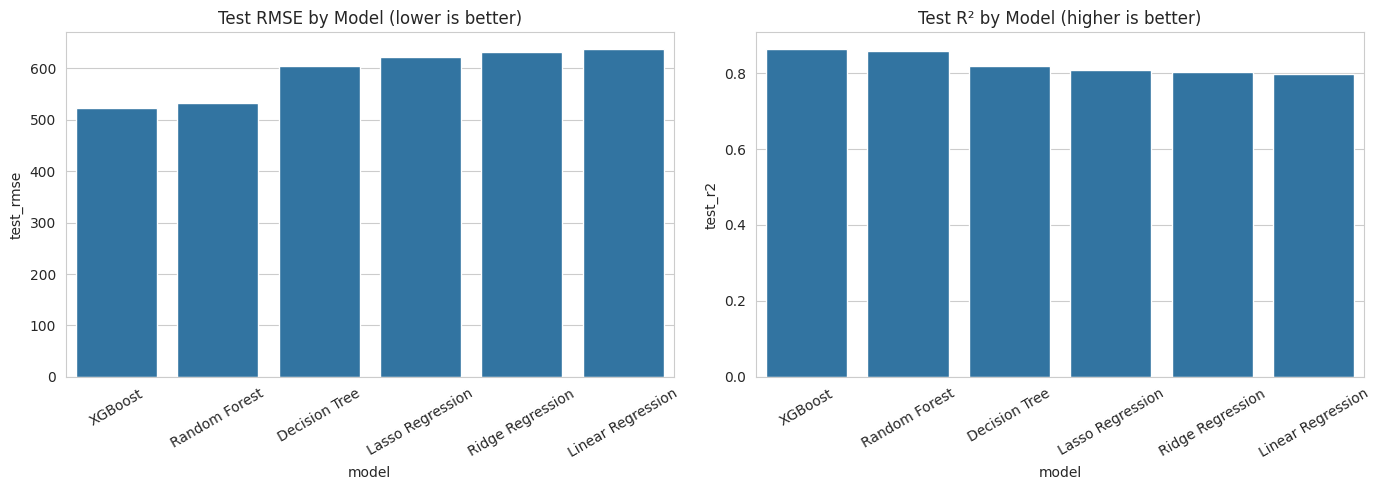

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=results_df, x="model", y="test_rmse", ax=axes[0])
axes[0].set_title("Test RMSE by Model (lower is better)")
axes[0].tick_params(axis="x", rotation=30)
 
sns.barplot(data=results_df, x="model", y="test_r2", ax=axes[1])
axes[1].set_title("Test R² by Model (higher is better)")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()
 

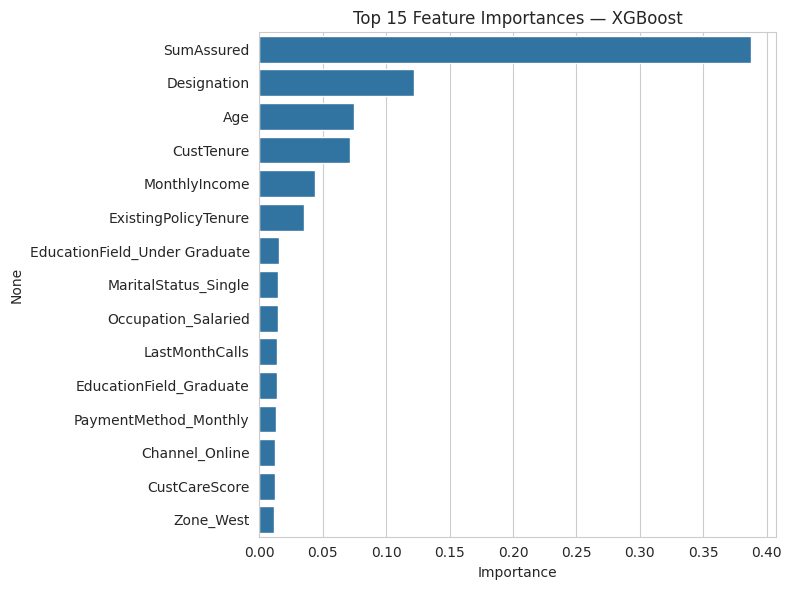

In [44]:
# ## Feature importance from the best tree-based model
# This directly answers the business objective: which factors actually
# drive agent bonuses. Useful for identifying what to coach lower-
# performing agents on.
 
# %%
best_row = results_df.iloc[0]
best_model_name = best_row["model"]
best_model = [r["fitted_model"] for r in results if r["model"] == best_model_name][0]
 
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
    importances = importances.sort_values(ascending=False).head(15)
 
    plt.figure(figsize=(8, 6))
    sns.barplot(x=importances.values, y=importances.index)
    plt.title(f"Top 15 Feature Importances — {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} has no built-in feature_importances_ "
          f"(this applies to linear models — check .coef_ instead).")


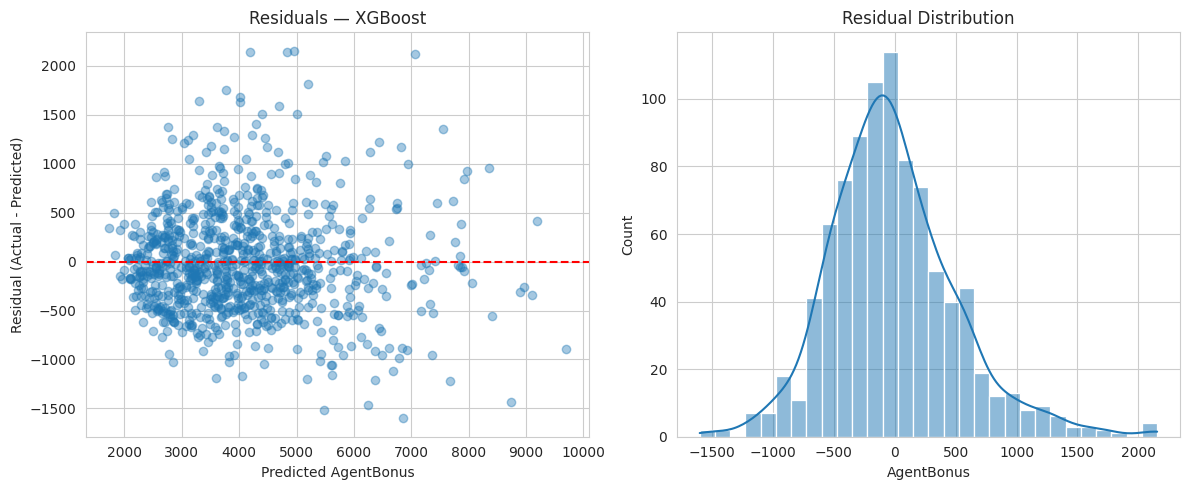

In [45]:
# Residual check on the best model
# Residuals should scatter randomly around 0 with no obvious pattern.
# A funnel shape (residuals growing with predicted value) would suggest
# the model struggles more on high-bonus agents — worth knowing before
# trusting predictions for your top performers.
 
# %%
best_preds = best_model.predict(X_test if best_model_name not in
                                  ["Linear Regression", "Ridge Regression", "Lasso Regression"]
                                  else X_test_scaled)
residuals = y_test - best_preds
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(best_preds, residuals, alpha=0.4)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted AgentBonus")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].set_title(f"Residuals — {best_model_name}")
 
sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_title("Residual Distribution")
plt.tight_layout()
plt.show()


In [46]:
print(f"\nBest model: {best_model_name}")
print(f"Test RMSE: {best_row['test_rmse']:.1f} (average error in bonus amount, in rupees)")
print(f"Test R²:   {best_row['test_r2']:.4f} (share of bonus variation explained by the model)")


Best model: XGBoost
Test RMSE: 522.9 (average error in bonus amount, in rupees)
Test R²:   0.8640 (share of bonus variation explained by the model)


# **Error analysis**

In [47]:
# ## 1. Find the worst-predicted rows
# Instead of guessing why errors happen, look directly at the specific
# rows with the biggest mistakes and see what they have in common.
 
# %%
preds = best_model.predict(X_test)
errors = y_test.values - preds
 
error_df = X_test.copy()
error_df["actual"] = y_test.values
error_df["predicted"] = preds
error_df["error"] = errors
error_df["abs_error"] = np.abs(errors)
 
worst = error_df.sort_values("abs_error", ascending=False).head(30)
print("Top 30 worst-predicted rows:")
worst[["actual", "predicted", "error", "SumAssured", "Designation",
       "MonthlyIncome", "Age", "CustTenure"]]
 

Top 30 worst-predicted rows:


,actual,predicted,error,SumAssured,Designation,MonthlyIncome,Age,CustTenure
4077,7108,4953.616211,2154.383789,838725.0,2,21474.0,21.0,21.0
2299,6976,4830.971680,2145.028320,704560.0,2,21474.0,14.0,7.0
4433,6330,4187.001953,2142.998047,651949.0,2,21928.0,13.0,19.0
2980,9181,7064.744629,2116.255371,1129202.0,4,36722.0,28.0,9.0
465,7026,5206.862793,1819.137207,723678.0,3,21474.0,28.0,7.0
2298,5516,3762.430420,1753.569580,595680.0,2,21474.0,6.0,6.0
3940,5691,4014.021729,1676.978271,648746.0,1,22763.0,11.0,17.0
3489,4935,3299.468750,1635.531250,503419.0,0,22434.0,10.0,5.0
3454,5651,4022.040771,1628.959229,570707.0,1,23544.0,17.0,11.0
2484,5252,6853.819824,-1601.819824,672230.0,3,35012.0,32.0,32.0


In [48]:
# ## 2. Compare worst-predicted rows against the overall dataset
# If a feature's average looks very different in the "worst" group vs
# everyone else, that feature likely interacts with something the model
# isn't capturing well — a strong candidate for feature engineering.
 
# %%
compare_cols = ["SumAssured", "MonthlyIncome", "Age", "CustTenure",
                 "Designation", "NumberOfPolicy", "ExistingPolicyTenure"]
 
comparison = pd.DataFrame({
    "worst_30_mean": worst[compare_cols].mean(),
    "overall_mean": X_test[compare_cols].mean(),
})
comparison["pct_diff"] = ((comparison["worst_30_mean"] - comparison["overall_mean"])
                            / comparison["overall_mean"] * 100).round(1)
print(comparison)
 


                      worst_30_mean   overall_mean  pct_diff
SumAssured            736736.933333  618381.575221      19.1
MonthlyIncome          25686.133333   22701.252765      13.1
Age                       16.466667      14.372788      14.6
CustTenure                16.633333      14.300885      16.3
Designation                1.933333       1.035398      86.7
NumberOfPolicy             3.700000       3.549779       4.2
ExistingPolicyTenure       5.700000       4.142699      37.6


In [49]:
# ## 3. Check under-predicted vs over-predicted separately
# Under-predictions (actual >> predicted) and over-predictions behave
# differently and may need different fixes.
 
# %%
under_predicted = error_df[error_df["error"] > 500].sort_values("error", ascending=False)
print(f"Under-predicted rows : {len(under_predicted)}")
print("\nSumAssured-to-MonthlyIncome ratio in under-predicted group vs overall:")
under_ratio = (under_predicted["SumAssured"] / under_predicted["MonthlyIncome"]).mean()
overall_ratio = (X_test["SumAssured"] / X_test["MonthlyIncome"]).mean()
print(f"Under-predicted group: {under_ratio:.1f}   |   Overall: {overall_ratio:.1f}")
 

Under-predicted rows : 135

SumAssured-to-MonthlyIncome ratio in under-predicted group vs overall:
Under-predicted group: 28.1   |   Overall: 27.3


# **Asymmetric Cost Model**

In [50]:
# Standard RMSE/MAE treat under-predicting and over-predicting a bonus as
# equally bad. But a CFO cares more about under-predicting (leads to
# budget shortfall) than over-predicting (leads to a small surplus).
# XGBoost's native quantile objective lets us bias predictions upward
# on purpose. alpha=0.5 is the median (roughly equivalent to the
# original symmetric model); alpha > 0.5 shifts predictions higher,
# trading some accuracy for fewer under-predictions.

quantile_results = []

for alpha in [0.5, 0.6, 0.65, 0.7, 0.75]:
    xgb_q = XGBRegressor(
        objective="reg:quantileerror",
        quantile_alpha=alpha,
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
    )
    xgb_q.fit(X_train, y_train)
    preds_q = xgb_q.predict(X_test)

    under_rate = (preds_q < y_test.values).mean()
    rmse = np.sqrt(mean_squared_error(y_test, preds_q))
    mae = mean_absolute_error(y_test, preds_q)
    r2 = r2_score(y_test, preds_q)

    quantile_results.append({
        "alpha": alpha, "rmse": rmse, "mae": mae, "r2": r2,
        "under_prediction_rate": under_rate, "model": xgb_q,
    })

    print(f"alpha={alpha}: RMSE={rmse:.1f}  MAE={mae:.1f}  "
          f"R²={r2:.4f}  under-prediction rate={under_rate*100:.1f}%")

alpha=0.5: RMSE=525.4  MAE=385.8  R²=0.8627  under-prediction rate=45.1%
alpha=0.6: RMSE=540.7  MAE=414.7  R²=0.8546  under-prediction rate=38.5%
alpha=0.65: RMSE=556.2  MAE=431.1  R²=0.8462  under-prediction rate=32.5%
alpha=0.7: RMSE=588.5  MAE=459.6  R²=0.8278  under-prediction rate=28.8%
alpha=0.75: RMSE=634.9  MAE=494.2  R²=0.7996  under-prediction rate=26.1%


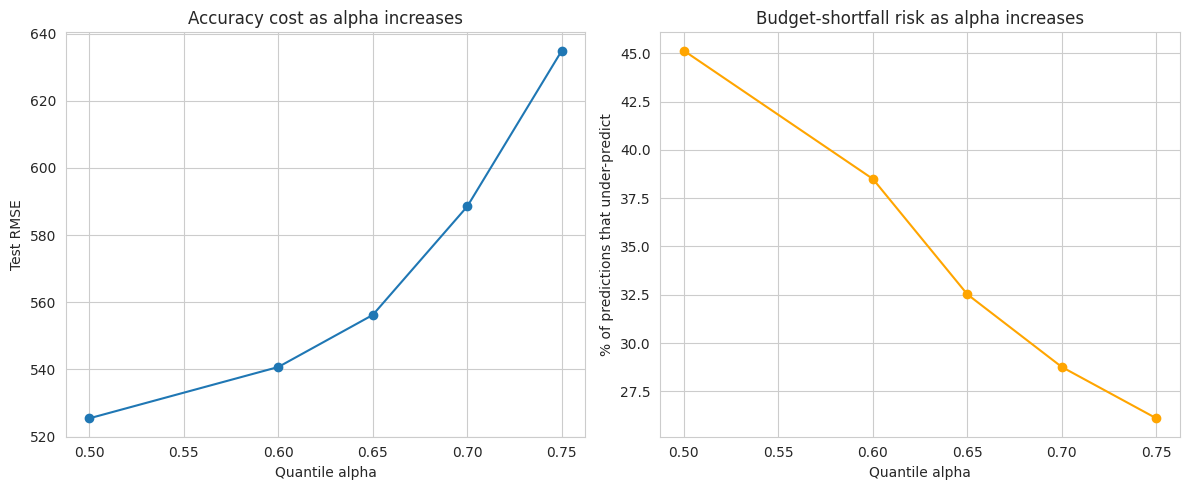

 alpha       rmse        mae       r2  under_prediction_rate  rmse_cost_per_pp_reduction
  0.50 525.423252 385.817810 0.862743               0.451327                         NaN
  0.60 540.713042 414.689423 0.854638               0.384956                    2.303662
  0.65 556.218398 431.079437 0.846182               0.325221                    2.595711
  0.70 588.536240 459.559814 0.827788               0.287611                    8.592744
  0.75 634.930926 494.234802 0.799567               0.261062                   17.475332


In [51]:
quantile_df = pd.DataFrame(quantile_results)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(quantile_df["alpha"], quantile_df["rmse"], marker="o")
axes[0].set_xlabel("Quantile alpha")
axes[0].set_ylabel("Test RMSE")
axes[0].set_title("Accuracy cost as alpha increases")

axes[1].plot(quantile_df["alpha"], quantile_df["under_prediction_rate"] * 100,
             marker="o", color="orange")
axes[1].set_xlabel("Quantile alpha")
axes[1].set_ylabel("% of predictions that under-predict")
axes[1].set_title("Budget-shortfall risk as alpha increases")
plt.tight_layout()
plt.show()

# How much RMSE does each step "cost" per percentage point of
# under-prediction risk it removes? A rising number here means
# diminishing returns — past that point, you're paying a lot more
# accuracy for a little less risk.
quantile_df["rmse_cost_per_pp_reduction"] = (
    quantile_df["rmse"].diff() / (-quantile_df["under_prediction_rate"].diff() * 100)
)
print(quantile_df[["alpha", "rmse", "mae", "r2",
                    "under_prediction_rate", "rmse_cost_per_pp_reduction"]]
      .to_string(index=False))

In [52]:
# Picking alpha: RMSE cost per point of under-prediction risk removed
# stays cheap (~2.3-2.6 RMSE/pp) from 0.50 through 0.65, then jumps to
# 8.6 RMSE/pp at 0.70 and 17.5 RMSE/pp at 0.75 — a clear efficiency
# cliff. alpha=0.65 captures nearly all the "cheap" risk reduction
# (under-prediction rate 45.1% -> 32.5%) before returns collapse.
# Raise it further only if leadership explicitly wants to pay extra
# accuracy for marginal additional safety.
chosen_alpha = 0.65

final_asymmetric_model = [r["model"] for r in quantile_results if r["alpha"] == chosen_alpha][0]
final_preds = final_asymmetric_model.predict(X_test)

print(f"Final asymmetric model (alpha={chosen_alpha}):")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, final_preds)):.1f}")
print(f"MAE:  {mean_absolute_error(y_test, final_preds):.1f}")
print(f"R²:   {r2_score(y_test, final_preds):.4f}")
print(f"Under-prediction rate: {(final_preds < y_test.values).mean()*100:.1f}%")

Final asymmetric model (alpha=0.65):
RMSE: 556.2
MAE:  431.1
R²:   0.8462
Under-prediction rate: 32.5%


# **SHAP Model**

In [53]:
## Add engineered features
# Same features tested earlier in error analysis — combining the
# strongest predictors (SumAssured, Designation) since the EDA showed
# their relationship isn't purely additive (senior agents' bonuses
# scale differently with SumAssured than junior agents' do).
 
# %%
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()
 
for df_fe in [X_train_fe, X_test_fe]:
    df_fe["SumAssured_to_Income"] = df_fe["SumAssured"] / df_fe["MonthlyIncome"].replace(0, np.nan)
    df_fe["Income_per_Tenure"] = df_fe["MonthlyIncome"] / (df_fe["CustTenure"] + 1)
    df_fe["Designation_x_SumAssured"] = df_fe["Designation"] * df_fe["SumAssured"]
    df_fe["Policies_per_Tenure"] = df_fe["NumberOfPolicy"] / (df_fe["CustTenure"] + 1)
 
X_train_fe = X_train_fe.replace([np.inf, -np.inf], np.nan).fillna(X_train_fe.median(numeric_only=True))
X_test_fe = X_test_fe.replace([np.inf, -np.inf], np.nan).fillna(X_train_fe.median(numeric_only=True))
 
print("Feature count:", X_train_fe.shape[1], "(was", X_train.shape[1], ")")
 


Feature count: 34 (was 30 )


In [54]:
##  Re-tune hyperparameters specifically for the asymmetric objective
# The earlier tuning (RandomizedSearchCV) optimized for plain RMSE using
# the SYMMETRIC model. That's not the right target now — we're using
# quantile_alpha=0.65, so hyperparameters should be chosen to minimize
# PINBALL LOSS at that same alpha, not plain RMSE. Otherwise we're
# tuning for one objective and deploying another.
 
# %%
CHOSEN_ALPHA = 0.65
 
pinball_scorer = make_scorer(mean_pinball_loss, alpha=CHOSEN_ALPHA, greater_is_better=False)
 

In [55]:
param_dist = {
    "n_estimators": [200, 300, 400, 600, 800],
    "max_depth": [3, 4, 5, 6, 7],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [0.5, 1, 1.5, 2],
}
 
xgb_q_base = XGBRegressor(
    objective="reg:quantileerror",
    quantile_alpha=CHOSEN_ALPHA,
    random_state=42,
    n_jobs=-1,
)
 
search = RandomizedSearchCV(
    xgb_q_base,
    param_distributions=param_dist,
    n_iter=40,
    scoring=pinball_scorer,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
 
search.fit(X_train_fe, y_train)
 
print("Best params:", search.best_params_)
print("Best CV pinball loss:", -search.best_score_)
 


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params: {'subsample': 1.0, 'reg_lambda': 1.5, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 7, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best CV pinball loss: 190.37265207288857


In [56]:
## Evaluate the final model on the held-out test set
 
# %%
final_model = search.best_estimator_
final_preds = final_model.predict(X_test_fe)
 
final_rmse = np.sqrt(mean_squared_error(y_test, final_preds))
final_mae = mean_absolute_error(y_test, final_preds)
final_r2 = r2_score(y_test, final_preds)
final_under_rate = (final_preds < y_test.values).mean()
final_pinball = mean_pinball_loss(y_test, final_preds, alpha=CHOSEN_ALPHA)
 
print("FINAL MODEL — engineered features + tuned for pinball loss @ alpha=0.65")
print(f"RMSE: {final_rmse:.1f}")
print(f"MAE:  {final_mae:.1f}")
print(f"R²:   {final_r2:.4f}")
print(f"Under-prediction rate: {final_under_rate*100:.1f}%")
print(f"Pinball loss @ alpha={CHOSEN_ALPHA}: {final_pinball:.1f}")
print()
print("Compare to untuned alpha=0.65 quantile model from before:")
print("RMSE: 556.2 | R²: 0.8462 | Under-prediction rate: 32.5%")
 

FINAL MODEL — engineered features + tuned for pinball loss @ alpha=0.65
RMSE: 550.4
MAE:  418.4
R²:   0.8494
Under-prediction rate: 34.6%
Pinball loss @ alpha=0.65: 184.4

Compare to untuned alpha=0.65 quantile model from before:
RMSE: 556.2 | R²: 0.8462 | Under-prediction rate: 32.5%


In [57]:
## 4. SHAP — per-feature, per-agent explainability
# Feature importance (used earlier) only tells you which features matter
# ON AVERAGE across all agents. SHAP tells you, for a SPECIFIC agent,
# exactly how much each feature pushed their predicted bonus up or down
# — directly useful for explaining to an individual agent or manager
# why a particular prediction came out the way it did.
 
# %%
import shap
 
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_fe)


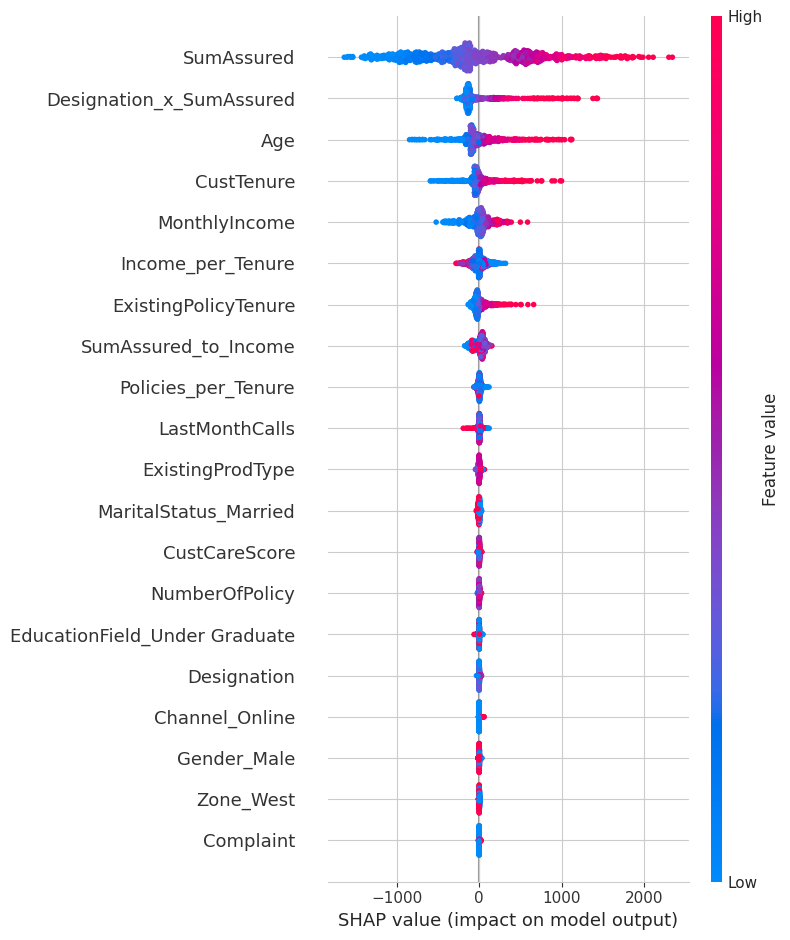

In [58]:
# Global view: which features matter most overall (like feature importance,
# but shows direction — red=high value pushed bonus up, blue=pushed down)
shap.summary_plot(shap_values, X_test_fe, show=False)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=100, bbox_inches="tight")
plt.show()
 

In [59]:
# Local view: explain ONE specific agent's prediction (row 0 of the test set)
# — this is what you'd show a manager asking "why did this agent get this bonus?"
agent_idx = 0
print(f"Agent (test row {agent_idx}):")
print(f"  Actual bonus:    {y_test.iloc[agent_idx]:.0f}")
print(f"  Predicted bonus: {final_preds[agent_idx]:.0f}")
print()
print("Top features driving this specific prediction:")
shap_row = pd.Series(shap_values[agent_idx], index=X_test_fe.columns).sort_values(key=abs, ascending=False)
print(shap_row.head(8))

Agent (test row 0):
  Actual bonus:    4073
  Predicted bonus: 4065

Top features driving this specific prediction:
SumAssured                  366.115845
Age                        -240.743881
Designation_x_SumAssured   -233.646423
Income_per_Tenure          -131.688980
ExistingPolicyTenure        127.839600
CustTenure                  -89.370445
SumAssured_to_Income         40.784485
MonthlyIncome               -17.543356
dtype: float32


Tier cutoffs (from training predictions):
  Struggling:  predicted bonus < 3265
  Core:        3265 <= predicted bonus <= 4889
  Superstar:   predicted bonus > 4889
tier
Struggling    229
Core          451
Superstar     224
Name: count, dtype: int64
                   mean  count
tier                          
Struggling  2581.908297    229
Core        3905.082040    451
Superstar   5832.535714    224


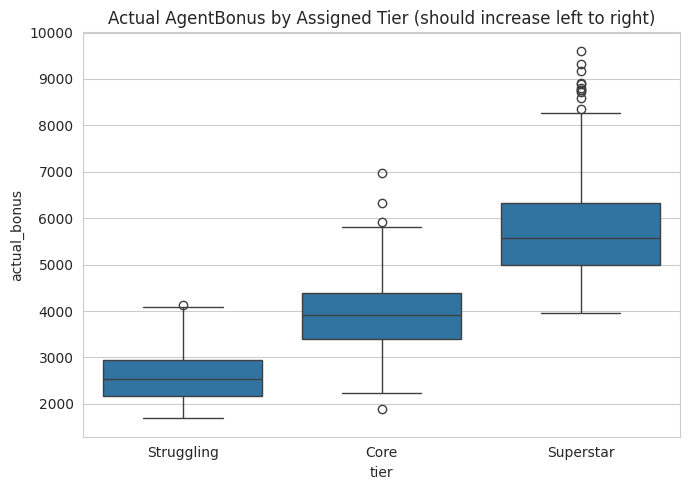

Spread of actual bonus WITHIN each tier:
             min   max  range
tier                         
Struggling  1688  4135   2447
Core        1883  6976   5093
Superstar   3967  9608   5641
Saved: tier_config.pkl


In [60]:
# %% [markdown]
# # Agent Bonus Prediction — Business Tier Reporting Layer
# Kaggle notebook: paste each `# %%` block as a separate cell.
# Run after 05_final_model_shap_export.py (needs final_model, X_train_fe,
# X_test_fe, y_train, y_test in memory).
#
# IMPORTANT: this does NOT replace the regression model. It's a
# reporting/display layer on top of it. The underlying number
# (predicted bonus in rupees) stays the source of truth; the tier
# label is only for dashboards and quick human scanning. This is the
# actual fix for the "executive review" critique's valid concern about
# readability, without the problems a full classification pivot would
# introduce (loses precision, reintroduces boundary cliffs at tier
# edges instead of removing them).

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# %% [markdown]
# ## 1. Define tier thresholds from the TRAINING set only
# Using percentiles rather than fixed rupee amounts, so tiers stay
# meaningful even if overall bonus levels shift over time (e.g. after
# a raise across the board). Thresholds are computed on the model's
# PREDICTIONS on training data, not on actual training bonuses — this
# keeps the tiering consistent with what the model itself outputs,
# which matters since the model is the thing being deployed.
#
# Split: bottom 25% = Struggling, middle 50% = Core, top 25% = Superstar.
# Change these cut points if the business defines tiers differently —
# this is a reporting convention, not a statistical requirement.

# %%
train_preds_for_tiers = final_model.predict(X_train_fe)

tier_low_cutoff = np.percentile(train_preds_for_tiers, 25)
tier_high_cutoff = np.percentile(train_preds_for_tiers, 75)

print(f"Tier cutoffs (from training predictions):")
print(f"  Struggling:  predicted bonus < {tier_low_cutoff:.0f}")
print(f"  Core:        {tier_low_cutoff:.0f} <= predicted bonus <= {tier_high_cutoff:.0f}")
print(f"  Superstar:   predicted bonus > {tier_high_cutoff:.0f}")

# %%
def assign_tier(predicted_bonus, low_cutoff, high_cutoff):
    """Bucket a predicted bonus into a business-facing tier label.
    Takes a scalar or array; returns matching scalar or array of labels."""
    predicted_bonus = np.asarray(predicted_bonus)
    tiers = np.where(predicted_bonus < low_cutoff, "Struggling",
             np.where(predicted_bonus > high_cutoff, "Superstar", "Core"))
    return tiers if tiers.shape else tiers.item()

# %% [markdown]
# ## 2. Build the reporting table for the test set
# This is what would actually get shown on a manager's dashboard —
# agent-level rows with both the precise number AND the tier label,
# so nothing is lost compared to a pure regression output.

# %%
test_preds = final_model.predict(X_test_fe)

report_df = X_test_fe.copy()
report_df["actual_bonus"] = y_test.values
report_df["predicted_bonus"] = test_preds
report_df["tier"] = assign_tier(test_preds, tier_low_cutoff, tier_high_cutoff)

tier_order = ["Struggling", "Core", "Superstar"]
report_df["tier"] = pd.Categorical(report_df["tier"], categories=tier_order, ordered=True)

print(report_df["tier"].value_counts().reindex(tier_order))
report_df[["actual_bonus", "predicted_bonus", "tier"]].head(10)

# %% [markdown]
# ## 3. Sanity check — does the tier actually track real performance?
# If tiering is doing its job, the AVERAGE ACTUAL bonus should increase
# cleanly from Struggling -> Core -> Superstar. If it doesn't, the
# cutoffs (or the model) need revisiting before this goes on a dashboard.

# %%
tier_check = report_df.groupby("tier", observed=True)["actual_bonus"].agg(["mean", "count"])
print(tier_check)

plt.figure(figsize=(7, 5))
sns.boxplot(data=report_df, x="tier", y="actual_bonus", order=tier_order)
plt.title("Actual AgentBonus by Assigned Tier (should increase left to right)")
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 4. Quantify what tiering loses vs. keeping the raw number
# This directly answers the "does bucketing throw away useful
# information" question from the earlier critique review — with a
# real number instead of a guess.

# %%
# Within EACH tier, how much does the actual bonus still vary?
# A wide spread means two agents in the same tier can still have very
# different real performance — exactly the information a pure tier
# label would hide, which is why the underlying number should still be
# shown alongside the tier on any dashboard, not instead of it.
spread_by_tier = report_df.groupby("tier", observed=True)["actual_bonus"].agg(
    ["min", "max", lambda x: x.max() - x.min()]
)
spread_by_tier.columns = ["min", "max", "range"]
print("Spread of actual bonus WITHIN each tier:")
print(spread_by_tier)

# %% [markdown]
# ## 5. Save the tier cutoffs alongside the model artifacts
# So any future prediction pipeline (including the standalone inference
# script) can assign tiers the same way without recomputing cutoffs.

# %%
import joblib

tier_config = {
    "low_cutoff": float(tier_low_cutoff),
    "high_cutoff": float(tier_high_cutoff),
    "tier_order": tier_order,
    "definition": "bottom 25% / middle 50% / top 25% of predicted bonus on training data",
}
joblib.dump(tier_config, "tier_config.pkl")
print("Saved: tier_config.pkl")
